In [125]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# まずは重回帰でやってみる
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
# 次にLightGBMでやってみる
#import lightgbm as lgb
# matplotlibで日本語を使えるように設定
import japanize_matplotlib

In [126]:
# データの読み込みとそれぞれの確認

# 学習用試合データ
try:
    df_train_match_data = pd.read_csv("data/train_Jleague.csv", encoding="utf-8")
    print(f"{df_train_match_data.head(3)}\n")
except:
    print("ファイルが見つかりません")

# 学習用試合追加データ
try:
    df_train_match_add_data = pd.read_csv("data/train_add.csv", encoding="utf-8")
    print(f"{df_train_match_add_data.head(3)}\n")
except:
    print("ファイルが見つかりません")
    
# 2014年度後半試合追加データ
try:
    df_train_2014_match_add_data = pd.read_csv("data/2014_add.csv", encoding="utf-8")
    print(f"{df_train_2014_match_add_data.head(3)}\n")
except:
    print("ファイルが見つかりません")

# スタジアムデータ
try:
    df_stadium_data = pd.read_csv("data/stadium.csv", encoding="utf-8")
    print(f"{df_stadium_data.head(3)}\n")
except:
    print("ファイルが見つかりません")

# 試合詳細データ
try:
    df_match_condition_data = pd.read_csv("data/condition.csv", encoding="utf-8")
    print(f"{df_match_condition_data.head(3)}\n")
except:
    print("ファイルが見つかりません")

# 試合詳細追加データ
try:
    df_match_condition_add_data = pd.read_csv("data/condition_add.csv", encoding="utf-8")
    print(f"{df_match_condition_add_data.head(3)}\n")
except:
    print("ファイルが見つかりません")

# 評価用試合データ
try:
    df_test_data = pd.read_csv("data/test_Jleague.csv", encoding="utf-8")
    print(f"{df_test_data.head(3)}\n")
except:
    print("ファイルが見つかりません")






      id      y  year stage   match   gameday   time      home      away  \
0  13994  18250  2012    Ｊ１  第１節第１日  03/10(土)  14:04    ベガルタ仙台  鹿島アントラーズ   
1  13995  24316  2012    Ｊ１  第１節第１日  03/10(土)  14:04  名古屋グランパス   清水エスパルス   
2  13996  17066  2012    Ｊ１  第１節第１日  03/10(土)  14:04     ガンバ大阪   ヴィッセル神戸   

        stadium                                tv  
0  ユアテックスタジアム仙台               スカパー／ｅ２／スカパー光／ＮＨＫ総合  
1       豊田スタジアム  スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯＲＴＳ　４）／ＮＨＫ名古屋  
2       万博記念競技場   スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯＲＴＳ　１）／ＮＨＫ大阪  

      id      y  year stage   match   gameday   time      home      away  \
0  14003  19010  2012    Ｊ１  第２節第１日  03/17(土)  14:04  鹿島アントラーズ  川崎フロンターレ   
1  14020  15072  2012    Ｊ１  第３節第２日  03/25(日)  19:03     ガンバ大阪    ジュビロ磐田   
2  14023  25743  2012    Ｊ１  第４節第１日  03/31(土)  15:03     浦和レッズ  川崎フロンターレ   

          stadium                   tv  
0  県立カシマサッカースタジアム  スカパー／ｅ２／スカパー光／ＮＨＫ水戸  
1         万博記念競技場        スカパー／ｅ２／スカパー光  
2     埼玉スタジアム２００２    スカパー／ｅ２／スカパー光／テレ玉  

      id  year s

In [23]:
print(f"{df_test_data.head(3)}\n")
print(f"{df_train_match_data.head(3)}\n")
print(f"{df_train_2014_match_add_data.head(3)}\n")

      id  year stage    match   gameday   time      home       away  \
0  15822  2014    Ｊ１  第１８節第１日  08/02(土)  19:04    ベガルタ仙台  大宮アルディージャ   
1  15823  2014    Ｊ１  第１８節第１日  08/02(土)  18:34  鹿島アントラーズ  サンフレッチェ広島   
2  15824  2014    Ｊ１  第１８節第１日  08/02(土)  19:04     浦和レッズ    ヴィッセル神戸   

          stadium                                tv  
0    ユアテックスタジアム仙台              スカパー！／スカパー！プレミアムサービス  
1  県立カシマサッカースタジアム              スカパー！／スカパー！プレミアムサービス  
2     埼玉スタジアム２００２  スカパー！／スカパー！プレミアムサービス／ＮＨＫ　ＢＳ１／テレ玉  

      id      y  year stage   match   gameday   time      home      away  \
0  13994  18250  2012    Ｊ１  第１節第１日  03/10(土)  14:04    ベガルタ仙台  鹿島アントラーズ   
1  13995  24316  2012    Ｊ１  第１節第１日  03/10(土)  14:04  名古屋グランパス   清水エスパルス   
2  13996  17066  2012    Ｊ１  第１節第１日  03/10(土)  14:04     ガンバ大阪   ヴィッセル神戸   

        stadium                                tv  
0  ユアテックスタジアム仙台               スカパー／ｅ２／スカパー光／ＮＨＫ総合  
1       豊田スタジアム  スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯＲＴＳ　４）／ＮＨＫ名古屋  
2       万博記念競技場   スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯ

In [15]:
print(f"{df_train_2014_match_add_data.head(3)}\n")

      id  year stage    match   gameday   time     home      away  \
0  15826  2014    Ｊ１  第１８節第１日  08/02(土)  18:34     ＦＣ東京   清水エスパルス   
1  15835  2014    Ｊ１  第１９節第１日  08/09(土)  18:04  清水エスパルス  徳島ヴォルティス   
2  15837  2014    Ｊ１  第１９節第１日  08/09(土)  19:04   セレッソ大阪      ＦＣ東京   

       stadium                             tv  
0     味の素スタジアム  スカパー！／スカパー！プレミアムサービス／ＴＯＫＹＯ　ＭＸ  
1  ＩＡＩスタジアム日本平           スカパー！／スカパー！プレミアムサービス  
2  ヤンマースタジアム長居           スカパー！／スカパー！プレミアムサービス  



In [17]:
print(f"{df_stadium_data.head(3)}\n")

          name           address   capa
0  名古屋市瑞穂陸上競技場  愛知県名古屋市瑞穂区山下通5-1  20000
1      豊田スタジアム      愛知県豊田市千石町7-2  40000
2    フクダ電子アリーナ  千葉県千葉市中央区川崎町1-20  18500



In [18]:
print(f"{df_match_condition_data.head(3)}\n")
print(f"{df_match_condition_add_data.head(3)}\n")

      id  home_score  away_score weather  temperature humidity referee  \
0  13994           1           0       雨          3.8      66%   木村　博之   
1  13995           1           0      屋内         12.4      43%   西村　雄一   
2  13996           2           3    晴一時雨         11.3      41%   高山　啓義   

  home_team home_01 home_02  ... away_02 away_03        away_04 away_05  \
0    ベガルタ仙台    林　卓人   菅井　直樹  ...   新井場　徹   岩政　大樹          中田　浩二   アレックス   
1  名古屋グランパス   楢﨑　正剛   田中　隼磨  ...    吉田　豊   岩下　敬輔  カルフィン　ヨン　ア　ピン    李　記帝   
2     ガンバ大阪  藤ヶ谷　陽介    加地　亮  ...   近藤　岳登  北本　久仁衛         伊野波　雅彦   相馬　崇人   

  away_06 away_07 away_08 away_09 away_10 away_11  
0    青木　剛   増田　誓志  小笠原　満男   本山　雅志   大迫　勇也  ジュニーニョ  
1   村松　大輔   河井　陽介   枝村　匠馬   高木　俊幸   アレックス   大前　元紀  
2   三原　雅俊   田中　英雄   野沢　拓也   橋本　英郎   森岡　亮太  大久保　嘉人  

[3 rows x 31 columns]

      id  home_score  away_score weather  temperature humidity referee  \
0  14003           0           1       雨         13.3      86%   西村　雄一   
1  14020           1  

In [19]:
print(f"{df_test_data.head(3)}\n")

      id  year stage    match   gameday   time      home       away  \
0  15822  2014    Ｊ１  第１８節第１日  08/02(土)  19:04    ベガルタ仙台  大宮アルディージャ   
1  15823  2014    Ｊ１  第１８節第１日  08/02(土)  18:34  鹿島アントラーズ  サンフレッチェ広島   
2  15824  2014    Ｊ１  第１８節第１日  08/02(土)  19:04     浦和レッズ    ヴィッセル神戸   

          stadium                                tv  
0    ユアテックスタジアム仙台              スカパー！／スカパー！プレミアムサービス  
1  県立カシマサッカースタジアム              スカパー！／スカパー！プレミアムサービス  
2     埼玉スタジアム２００２  スカパー！／スカパー！プレミアムサービス／ＮＨＫ　ＢＳ１／テレ玉  



In [127]:
# 学習用試合データと追加データを結合する。
train_full_data = pd.concat([df_train_match_data, df_train_match_add_data,], ignore_index=True)
print(f"{train_full_data.head(3)}\n")

print(df_train_match_data.shape, df_train_match_add_data.shape, train_full_data.shape)

# 試合詳細データと追加データを結合する
match_full_data = pd.concat([df_match_condition_data, df_match_condition_add_data,], ignore_index=True)
print(f"{match_full_data.head(3)}\n")
print(df_match_condition_data.shape, df_match_condition_add_data.shape, match_full_data.shape)

      id      y  year stage   match   gameday   time      home      away  \
0  13994  18250  2012    Ｊ１  第１節第１日  03/10(土)  14:04    ベガルタ仙台  鹿島アントラーズ   
1  13995  24316  2012    Ｊ１  第１節第１日  03/10(土)  14:04  名古屋グランパス   清水エスパルス   
2  13996  17066  2012    Ｊ１  第１節第１日  03/10(土)  14:04     ガンバ大阪   ヴィッセル神戸   

        stadium                                tv  
0  ユアテックスタジアム仙台               スカパー／ｅ２／スカパー光／ＮＨＫ総合  
1       豊田スタジアム  スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯＲＴＳ　４）／ＮＨＫ名古屋  
2       万博記念競技場   スカパー／ｅ２／スカパー光（Ｊ　ＳＰＯＲＴＳ　１）／ＮＨＫ大阪  

(1721, 11) (232, 11) (1953, 11)
      id  home_score  away_score weather  temperature humidity referee  \
0  13994           1           0       雨          3.8      66%   木村　博之   
1  13995           1           0      屋内         12.4      43%   西村　雄一   
2  13996           2           3    晴一時雨         11.3      41%   高山　啓義   

  home_team home_01 home_02  ... away_02 away_03        away_04 away_05  \
0    ベガルタ仙台    林　卓人   菅井　直樹  ...   新井場　徹   岩政　大樹          中田　浩二   アレックス   
1  名古屋グ

In [129]:
# train_full_dataとmatch_full_dataを結合する.train_full_dataに併せて、idで結合する。
train_full_data2 = train_full_data.merge(match_full_data, on="id", how="left")

print(f"{train_full_data2.head(3)}\n")
print(train_full_data2.shape)

# ついでにスタジアムも結合してしまう。スタジアム名で結合する。
# まずスタジアムのデータフレームのスタジアムの列名を変更する。
df_stadium_data.rename(columns={"name": "stadium"}, inplace=True)
train_full_data3 = train_full_data2.merge(df_stadium_data, on="stadium", how="left")

print(train_full_data3.columns)

# テストデータも同様に結合していく
test_full_data = df_test_data.merge(match_full_data, on="id", how="left")
test_full_data2 = test_full_data.merge(df_stadium_data, on="stadium", how="left")

      id      y  year stage   match   gameday   time      home      away  \
0  13994  18250  2012    Ｊ１  第１節第１日  03/10(土)  14:04    ベガルタ仙台  鹿島アントラーズ   
1  13995  24316  2012    Ｊ１  第１節第１日  03/10(土)  14:04  名古屋グランパス   清水エスパルス   
2  13996  17066  2012    Ｊ１  第１節第１日  03/10(土)  14:04     ガンバ大阪   ヴィッセル神戸   

        stadium  ... away_02  away_03        away_04 away_05  away_06 away_07  \
0  ユアテックスタジアム仙台  ...   新井場　徹    岩政　大樹          中田　浩二   アレックス     青木　剛   増田　誓志   
1       豊田スタジアム  ...    吉田　豊    岩下　敬輔  カルフィン　ヨン　ア　ピン    李　記帝    村松　大輔   河井　陽介   
2       万博記念競技場  ...   近藤　岳登   北本　久仁衛         伊野波　雅彦   相馬　崇人    三原　雅俊   田中　英雄   

  away_08 away_09 away_10 away_11  
0  小笠原　満男   本山　雅志   大迫　勇也  ジュニーニョ  
1   枝村　匠馬   高木　俊幸   アレックス   大前　元紀  
2   野沢　拓也   橋本　英郎   森岡　亮太  大久保　嘉人  

[3 rows x 41 columns]

(1953, 41)
Index(['id', 'y', 'year', 'stage', 'match', 'gameday', 'time', 'home', 'away',
       'stadium', 'tv', 'home_score', 'away_score', 'weather', 'temperature',
       'humidity', 'referee', 'hom

In [133]:
print(f"{test_full_data2.head(3)}\n")
print(f"{train_full_data3.head(3)}\n")

print(test_full_data2.shape)
print(train_full_data3.shape)


      id  year stage    match   gameday   time      home       away  \
0  15822  2014    Ｊ１  第１８節第１日  08/02(土)  19:04    ベガルタ仙台  大宮アルディージャ   
1  15823  2014    Ｊ１  第１８節第１日  08/02(土)  18:34  鹿島アントラーズ  サンフレッチェ広島   
2  15824  2014    Ｊ１  第１８節第１日  08/02(土)  19:04     浦和レッズ    ヴィッセル神戸   

          stadium                                tv  ...  away_04  away_05  \
0    ユアテックスタジアム仙台              スカパー！／スカパー！プレミアムサービス  ...    横山　知伸    高橋　祥平   
1  県立カシマサッカースタジアム              スカパー！／スカパー！プレミアムサービス  ...    水本　裕貴     柏　好文   
2     埼玉スタジアム２００２  スカパー！／スカパー！プレミアムサービス／ＮＨＫ　ＢＳ１／テレ玉  ...     大屋　翼    橋本　英郎   

  away_06  away_07 away_08 away_09 away_10  away_11           address   capa  
0   橋本　晃司    和田　拓也   家長　昭博   富山　貴光    ムルジャ     ズラタン   宮城県仙台市泉区七北田字柳78  19694  
1   柴﨑　晃誠    森﨑　和幸    山岸　智   石原　直樹  髙萩　洋次郎    佐藤　寿人   茨城県鹿嶋市神向寺後山26-2  40728  
2   杉浦　恭平     奥井　諒   高橋　峻希  小川　慶治朗   森岡　亮太  マルキーニョス  埼玉県さいたま市緑区中野田500  63700  

[3 rows x 42 columns]

      id      y  year stage   match   gameday   time      home

In [134]:
# 学習用のデータはいったん雑にできた。いったん、特徴量を整備せずに、ぶち込んで見ようかな。
# まずは欠損値・統計量の確認をする
print(train_full_data3.isnull().sum())


id             0
y              0
year           0
stage          0
match          0
gameday        0
time           0
home           0
away           0
stadium        0
tv             0
home_score     0
away_score     0
weather        0
temperature    0
humidity       0
referee        0
home_team      0
home_01        0
home_02        0
home_03        0
home_04        0
home_05        0
home_06        0
home_07        0
home_08        0
home_09        0
home_10        0
home_11        0
away_team      0
away_01        0
away_02        0
away_03        0
away_04        0
away_05        0
away_06        0
away_07        0
away_08        0
away_09        0
away_10        0
away_11        0
address        0
capa           0
dtype: int64


In [135]:
print(train_full_data3.describe())

                 id             y         year   home_score   away_score  \
count   1953.000000   1953.000000  1953.000000  1953.000000  1953.000000   
mean   15049.442396  10629.558116  2012.820276     1.366103     1.204301   
std      646.260483   8102.315189     0.758124     1.203060     1.125224   
min    13994.000000      0.000000  2012.000000     0.000000     0.000000   
25%    14482.000000   4687.000000  2012.000000     0.000000     0.000000   
50%    15044.000000   8594.000000  2013.000000     1.000000     1.000000   
75%    15532.000000  13471.000000  2013.000000     2.000000     2.000000   
max    16238.000000  62632.000000  2014.000000     7.000000     8.000000   

       temperature          capa  
count  1953.000000   1953.000000  
mean     20.438914  25688.549411  
std       6.438737  14016.934408  
min       1.400000   3560.000000  
25%      15.800000  15589.000000  
50%      21.400000  20246.000000  
75%      25.600000  30132.000000  
max      34.200000  72327.000000  


In [166]:
print(train_full_data3.head(1))
print(train_full_data3.columns)

print(train_full_data3["weather"].unique())


      id      y  year stage   match   gameday   time    home      away  \
0  13994  18250  2012    Ｊ１  第１節第１日  03/10(土)  14:04  ベガルタ仙台  鹿島アントラーズ   

        stadium  ... away_04  away_05  away_06 away_07  away_08 away_09  \
0  ユアテックスタジアム仙台  ...   中田　浩二    アレックス     青木　剛   増田　誓志   小笠原　満男   本山　雅志   

  away_10 away_11          address   capa  
0   大迫　勇也  ジュニーニョ  宮城県仙台市泉区七北田字柳78  19694  

[1 rows x 43 columns]
Index(['id', 'y', 'year', 'stage', 'match', 'gameday', 'time', 'home', 'away',
       'stadium', 'tv', 'home_score', 'away_score', 'weather', 'temperature',
       'humidity', 'referee', 'home_team', 'home_01', 'home_02', 'home_03',
       'home_04', 'home_05', 'home_06', 'home_07', 'home_08', 'home_09',
       'home_10', 'home_11', 'away_team', 'away_01', 'away_02', 'away_03',
       'away_04', 'away_05', 'away_06', 'away_07', 'away_08', 'away_09',
       'away_10', 'away_11', 'address', 'capa'],
      dtype='object')
['雨' '屋内' '晴一時雨' '曇一時雨のち晴' '晴' '曇' '晴時々曇' '雨のち曇' '曇時々雨' '曇時々晴' '

In [170]:
# データの前処理
# 自分流
# 観客動員数に影響がありそうな特徴量をピックアップする。（列数が多いので）

train_last_data = train_full_data3.copy()[["y", "stage", "gameday", "time", "home", "away", "stadium", "weather", "temperature", "humidity", "capa"]]
test_last_data = test_full_data2.copy()[["stage", "gameday", "time", "home", "away", "stadium", "weather", "temperature", "humidity", "capa"]]

# これを元に数値化とかデータをばらしていく。


# 天気だけ複雑なので、特別な手法で処理をする
def classify_weather(w):
    if w == "屋内":
        return "屋内"          # ドーム開催など。別扱いが妥当
    elif "雨" in w or "雷雨" in w:
        return "雨"            # 雨が少しでも絡むなら雨グループ
    elif "雪" in w:
        return "雪"
    elif "曇" in w:
        return "曇"
    elif "晴" in w:
        return "晴"
    else:
        return "その他"

train_last_data["weather_cat"] = train_last_data["weather"].apply(classify_weather)
train_last_data = pd.get_dummies(train_last_data, columns=["weather_cat"])

train_last_data["humidity"] = train_last_data["humidity"].str.extract(r"(\d+)").astype(float)
train_last_data["month"] = train_last_data["gameday"].str.extract(r"(\d+)").astype(int)
train_last_data["week"] = train_last_data["gameday"].str.extract(r"\((.+?)\)")
train_last_data["week"] = train_last_data["week"].map({"月": 0, "火": 1, "水": 2, "木": 3, "金": 4, "土": 5, "日": 6}).fillna(7)
train_last_data["time"] = train_last_data["time"].str.extract(r"(\d+)").astype(int)
train_last_data["cate"] = train_last_data["stage"].map({"Ｊ１": 0, "Ｊ２": 1})

# これをテストデータにも適用
test_last_data["weather_cat"] = test_last_data["weather"].apply(classify_weather)
test_last_data = pd.get_dummies(test_last_data, columns=["weather_cat"])

test_last_data["humidity"] = test_last_data["humidity"].str.extract(r"(\d+)").astype(float)
test_last_data["month"] = test_last_data["gameday"].str.extract(r"(\d+)").astype(int)
test_last_data["week"] = test_last_data["gameday"].str.extract(r"\((.+?)\)")
test_last_data["week"] = test_last_data["week"].map({"月": 0, "火": 1, "水": 2, "木": 3, "金": 4, "土": 5, "日": 6}).fillna(7)
test_last_data["time"] = test_last_data["time"].str.extract(r"(\d+)").astype(int)
test_last_data["cate"] = test_last_data["stage"].map({"Ｊ１": 0, "Ｊ２": 1})




# スタジアムのマッピング
stadium_list = train_last_data["stadium"].unique()
stadium_mapping = {stadium: i for i, stadium in enumerate(stadium_list)}
# チームのマッピング
team_list = train_last_data["home"].unique()
team_mapping = {team: i for i, team in enumerate(team_list)}

train_last_data["stadium_num"] = train_last_data["stadium"].map(stadium_mapping)
train_last_data["home_num"] = train_last_data["home"].map(team_mapping)
train_last_data["away_num"] = train_last_data["away"].map(team_mapping)

# これをテストデータにも適用
test_last_data["stadium_num"] = test_last_data["stadium"].map(stadium_mapping)
test_last_data["home_num"] = test_last_data["home"].map(team_mapping)
test_last_data["away_num"] = test_last_data["away"].map(team_mapping)


# 観客動員数に0があったのでその行を削除したい
train_last_data = train_last_data[train_last_data["y"] != 0]

print(train_last_data.columns)
print(test_last_data.columns)
print(train_last_data.shape, test_last_data.shape)
print(train_last_data.isnull().sum())
print(test_last_data.isnull().sum())

Index(['y', 'stage', 'gameday', 'time', 'home', 'away', 'stadium', 'weather',
       'temperature', 'humidity', 'capa', 'weather_cat_屋内', 'weather_cat_晴',
       'weather_cat_曇', 'weather_cat_雨', 'weather_cat_雪', 'month', 'week',
       'cate', 'stadium_num', 'home_num', 'away_num'],
      dtype='object')
Index(['stage', 'gameday', 'time', 'home', 'away', 'stadium', 'weather',
       'temperature', 'humidity', 'capa', 'weather_cat_屋内', 'weather_cat_晴',
       'weather_cat_曇', 'weather_cat_雨', 'weather_cat_雪', 'month', 'week',
       'cate', 'stadium_num', 'home_num', 'away_num'],
      dtype='object')
(1952, 22) (313, 21)
y                 0
stage             0
gameday           0
time              0
home              0
away              0
stadium           0
weather           0
temperature       0
humidity          0
capa              0
weather_cat_屋内    0
weather_cat_晴     0
weather_cat_曇     0
weather_cat_雨     0
weather_cat_雪     0
month             0
week              0
cate      

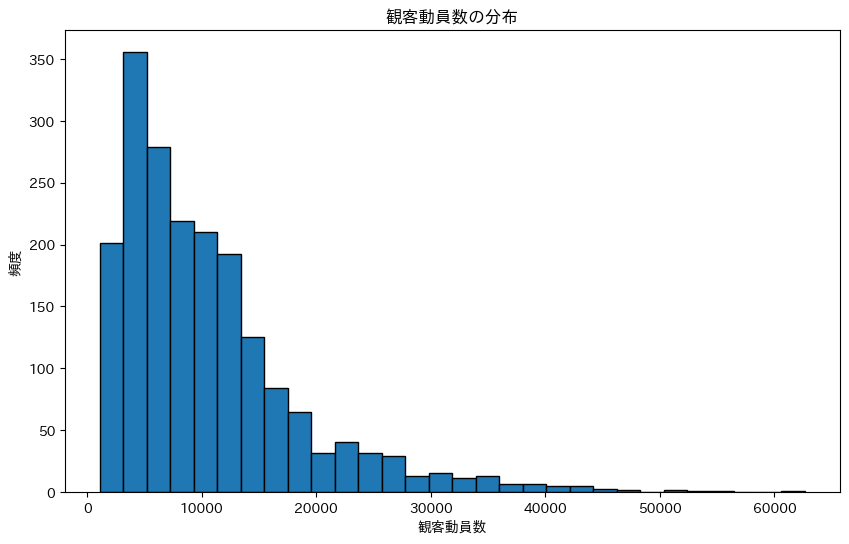

<Axes: >

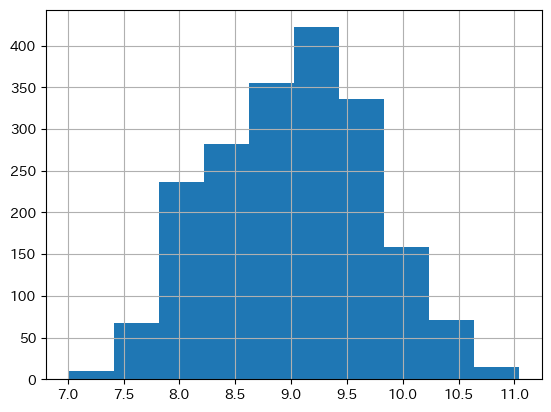

In [109]:
# データの可視化
# 観客動員数の分布
plt.figure(figsize=(10, 6))
plt.hist(train_last_data["y"], bins=30, edgecolor="black")
plt.title("観客動員数の分布")
plt.xlabel("観客動員数")
plt.ylabel("頻度")
plt.show()

np.log1p(train_last_data["y"]).hist()
#


Index(['y', 'stage', 'gameday', 'time', 'home', 'away', 'stadium', 'weather',
       'temperature', 'humidity', 'capa', 'month', 'week', 'cate',
       'stadium_num', 'home_num', 'away_num'],
      dtype='object')


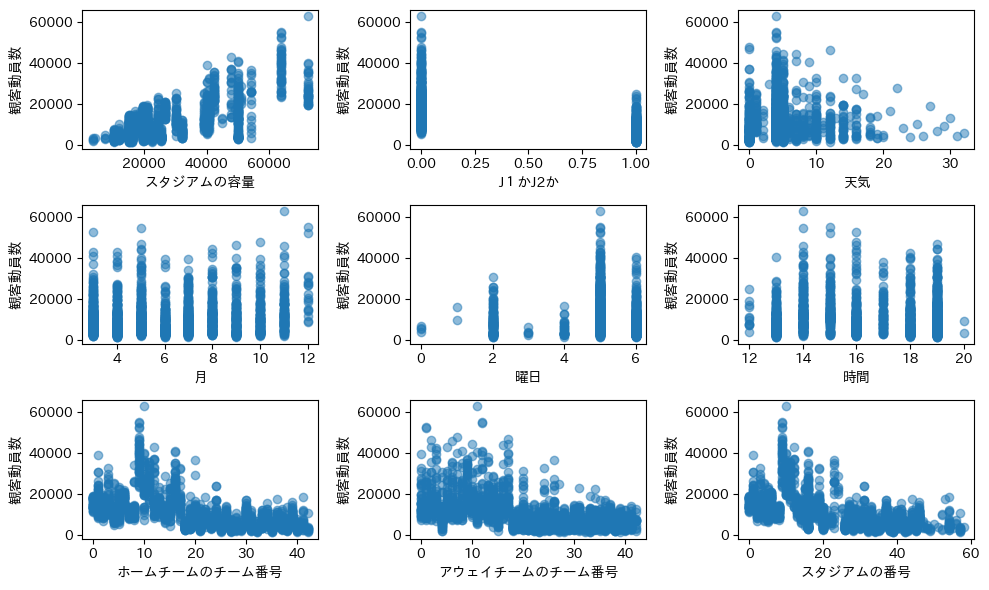

In [112]:
# データの可視化
# いろいろな散布図を見てみよう
# 観客動員数とスタジアムの容量の散布図
print(train_last_data.columns)
fig, axes = plt.subplots(3,3,figsize=(10,6))

axes[0,0].scatter(train_last_data["capa"], train_last_data["y"], alpha=0.5)
axes[0,0].set_xlabel("スタジアムの容量")
axes[0,0].set_ylabel("観客動員数")

axes[0,1].scatter(train_last_data["cate"], train_last_data["y"], alpha=0.5)
axes[0,1].set_xlabel("J１かJ2か")
axes[0,1].set_ylabel("観客動員数")

axes[0,2].scatter(train_last_data["weather"], train_last_data["y"], alpha=0.5)
axes[0,2].set_xlabel("天気")
axes[0,2].set_ylabel("観客動員数")

axes[1,0].scatter(train_last_data["month"], train_last_data["y"], alpha=0.5)
axes[1,0].set_xlabel("月")
axes[1,0].set_ylabel("観客動員数")

axes[1,1].scatter(train_last_data["week"], train_last_data["y"], alpha=0.5)
axes[1,1].set_xlabel("曜日")
axes[1,1].set_ylabel("観客動員数")

axes[1,2].scatter(train_last_data["time"], train_last_data["y"], alpha=0.5)
axes[1,2].set_xlabel("時間")
axes[1,2].set_ylabel("観客動員数")

axes[2,0].scatter(train_last_data["home_num"], train_last_data["y"], alpha=0.5)
axes[2,0].set_xlabel("ホームチームのチーム番号")
axes[2,0].set_ylabel("観客動員数")

axes[2,1].scatter(train_last_data["away_num"], train_last_data["y"], alpha=0.5)
axes[2,1].set_xlabel("アウェイチームのチーム番号")
axes[2,1].set_ylabel("観客動員数")

axes[2,2].scatter(train_last_data["stadium_num"], train_last_data["y"], alpha=0.5)
axes[2,2].set_xlabel("スタジアムの番号")
axes[2,2].set_ylabel("観客動員数")

plt.tight_layout()
plt.show()





In [185]:
# 学習するためのデータ整理
# まずは数値データのみにデータを絞る
train_last_data_num = train_last_data[["y", "capa", "cate", 'weather_cat_屋内', 'weather_cat_晴', 'weather_cat_曇', 'weather_cat_雨', 'weather_cat_雪', "month", "week", "time", "home_num", "away_num", "stadium_num"]]
test_last_data_num = test_last_data[["capa", "cate", 'weather_cat_屋内', 'weather_cat_晴', 'weather_cat_曇', 'weather_cat_雨', 'weather_cat_雪', "month", "week", "time", "home_num", "away_num", "stadium_num"]]

# そのあと、説明変数と目的変数に分ける。
X = train_last_data_num.drop("y", axis=1).to_numpy()
y = train_last_data_num["y"].to_numpy()

# まず分割する
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# そのあと、標準化をする
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape, X.shape, y.shape)

# 評価データを標準化する
X_last_test_scaled = scaler.transform(test_last_data_num.to_numpy())

# これで学習データとテストデータと評価データが用意できたので、学習→評価→予測を行う。


(1561, 13) (391, 13) (1561,) (391,) (1952, 13) (1952,)


In [186]:
# 重回帰で学習する

# モデルの作成
model = LinearRegression()
model.fit(X_train_scaled, y_train)



,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [188]:
# 学習データで決定係数を確認する
model.score(X_train_scaled, y_train)
#y_result = model.predict(X_train_scaled)
#y_result

0.66438316059707

In [189]:
# テストデータで決定係数を確認する
model.score(X_test_scaled, y_test)
#y_result2 = model.predict(X_test)

0.6998033737058457

In [190]:
# 評価用データで予測する
y_pred = model.predict(X_last_test_scaled)
y_pred

array([15152.03250832, 19968.99228124, 26360.19232255, 13482.92595885,
       20456.06445308, 14449.50628538, 11445.55909574, 15907.39331687,
       13038.67654923, 16022.09581057, 28481.11038399, 12620.21361967,
       19452.54768391, 14065.35022747, 14324.99521618, 18379.76099896,
       26147.46561476, 12511.44101592, 20158.66854717, 14882.84923776,
       11946.87398153, 15185.15506292, 15877.64815978, 13664.92349291,
       22380.3129591 , 12523.91518581, 19003.08734084, 13437.5481655 ,
       19885.89063629, 17410.23650861, 12986.91306322, 23101.39221979,
       18824.73318707, 26725.5633415 , 12270.69493127, 15172.05166292,
       15867.74470427, 14469.44286697, 14048.30792617, 21773.05648094,
       13034.79037802, 10923.58958687, 22324.18416608, 15733.72153724,
       29589.06340163, 13150.37603415, 22565.22634849, 22342.86750802,
       23815.65089766, 19113.84239332, 26930.00334963, 15917.81780063,
       13527.69453176, 14778.88153102, 20195.53334946, 23382.30794529,
      

<Axes: >

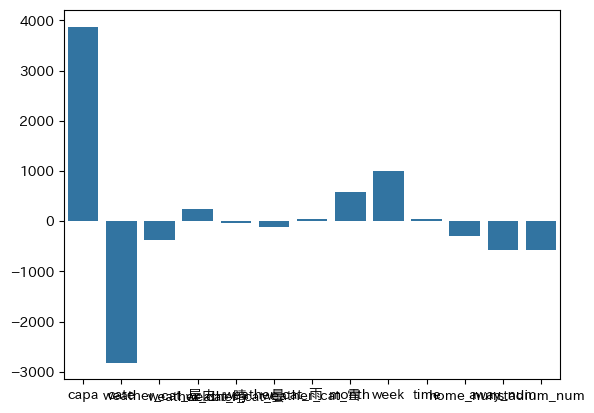

In [ ]:
import seaborn as sns

sns.barplot(x = ["capa", "cate", 'weather_cat_屋内', 'weather_cat_晴', 'weather_cat_曇', 'weather_cat_雨', 'weather_cat_雪', "month", "week", "time", "home_num", "away_num", "stadium_num"], y=model.coef_)




In [196]:
# 提出ファイル作成
submission_rf = pd.DataFrame({
    'id': test_full_data2['id'],
    '': y_pred
})
print(submission_rf.head())

submission_rf.to_csv('nsubmission.csv', header=False, index=False)
print("\nsubmission.csv を保存しました!")


      id              
0  15822  15152.032508
1  15823  19968.992281
2  15824  26360.192323
3  15825  13482.925959
4  15827  20456.064453

submission.csv を保存しました!


In [198]:
# ランダムフォレストで試してみる
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_forest = RandomForestRegressor(n_estimators=300, random_state=42)

model_forest.fit(X_train_scaled, y_train)

y_pred_test_data = model_forest.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_data))   # RMSE
mae  = mean_absolute_error(y_test, y_pred_test_data)           # MAE
r2   = r2_score(y_test, y_pred_test_data)                      # 決定係数 R²

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

y_pred_forest = model_forest.predict(X_last_test_scaled)
y_pred_forest

RMSE: 3885.39
MAE : 2302.77
R²  : 0.7971


array([14927.04333333, 15844.43966667, 35524.74666667, 10291.90333333,
       25994.05      , 15782.77      ,  6725.60666667, 15878.61666667,
       10535.75333333, 17880.44666667, 31114.66      , 11164.32666667,
       23589.52244444, 15997.82316667, 16701.72      , 13016.09083333,
       39119.53      , 12237.09      , 24946.97333333, 14090.75666667,
        8685.4       , 13442.14333333, 17837.14666667, 11454.97333333,
       26514.4       , 11891.47666667, 25561.62333333, 15548.81      ,
       23455.95222222, 15490.18133333, 12267.02333333, 17616.34666667,
       14901.2925    , 39180.39      ,  9781.23      , 15370.23333333,
       14240.93666667, 17226.78      , 13230.85      , 25258.22666667,
       10034.65666667, 11811.75333333, 23830.71666667, 15017.61333333,
       32467.85333333, 12494.32666667, 25556.95      , 27153.58      ,
       19033.74666667, 17917.3615    , 38385.45333333, 17630.44666667,
       13081.14      , 15052.2       , 17582.45      , 17168.49666667,
      

In [ ]:
# 提出ファイル作成
submission_forest_rf = pd.DataFrame({
    'id': test_full_data2['id'],
    '': y_pred_forest
})
print(submission_rf.head())

submission_forest_rf.to_csv('submission_forest.csv', header=False, index=False)
print("\nsubmission_forest.csv を保存しました!")

# 2531人中1289位


      id              
0  15822  15152.032508
1  15823  19968.992281
2  15824  26360.192323
3  15825  13482.925959
4  15827  20456.064453

submission_forest.csv を保存しました!
